# 🚀 Day 3: Logistic Regression & Classification Metrics

---

## 🎯 Learning Objectives
- ✅ Train a logistic regression classifier and obtain class probabilities  
- ✅ Explain why accuracy alone is misleading on imbalanced data  
- ✅ Read a confusion matrix and compute precision, recall, F1, and AUC-ROC  
- ✅ Decide whether precision or recall matters more for churn prediction  


## 🧪 Hands-On Lab: Building a Classifier
Step 1: Train a LogisticRegression model on churn data.

Step 2: Generate predictions and produce the confusion matrix.

Step 3: Compute precision, recall, and F1 with classification_report.

Step 4: Decide whether precision or recall matters more for churn and justify.

Step 5: Compute the AUC-ROC and document what it says about the model.

#### 🌱 Load Dataset and Split
We’ll use the Telco Customer Churn dataset from Kaggle.

In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.isnull().sum()
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df.head(3)



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [2]:
df = df.drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

X = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)
y = df["Churn"]

print(X.shape)
print(X.dtypes.value_counts())

(7043, 30)
bool       26
int64       2
float64     2
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 🌱 Step 1 — Train the Logistic Regression Model

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### 🔍 Step 2 — Confusion Matrix

In [5]:

predictions = model.predict(X_test_scaled)
probabilities = model.predict_proba(X_test_scaled)


Confusion Matrix:
 [[934 102]
 [151 222]]


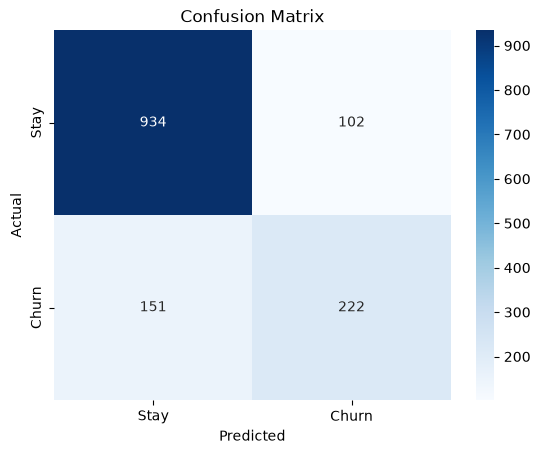

In [6]:
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stay","Churn"], yticklabels=["Stay","Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 📊 Step 3 — Precision, Recall, and F1



In [7]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409




- **Class 0 (Stay):** Precision = 0.86, Recall = 0.90, F1 = 0.88 → Strong performance on the majority class.  
- **Class 1 (Churn):** Precision = 0.69, Recall = 0.60, F1 = 0.64 → Moderate performance, many churners missed.  
- **Accuracy = 0.82:** Good overall, but imbalance means accuracy alone is misleading.  
- **Macro Avg (0.76 F1):** Shows weaker results on churn class.  
- **Weighted Avg (0.82 F1):** Looks stronger due to dominance of the majority class.

**Insight:** The model is reliable for non‑churners but weaker at catching churners. Improving recall is key for retention strategies.

### ⚖️ Step 4 — Precision vs. Recall Trade‑off

In churn prediction, the balance between precision and recall reflects a real business decision. High recall ensures that most churners are identified, which is vital for customer‑retention campaigns. However, improving recall often lowers precision, meaning more false alarms and wasted resources on customers who would have stayed. In this model, recall (0.60) shows moderate success in catching churners, while precision (0.69) indicates reasonable accuracy in those predictions. Depending on company goals, optimizing recall may be more valuable to prevent customer loss, even if it slightly reduces precision.


### 📈 Step 5 — AUC‑ROC Interpretation

AUC-ROC: 0.8621256741229931


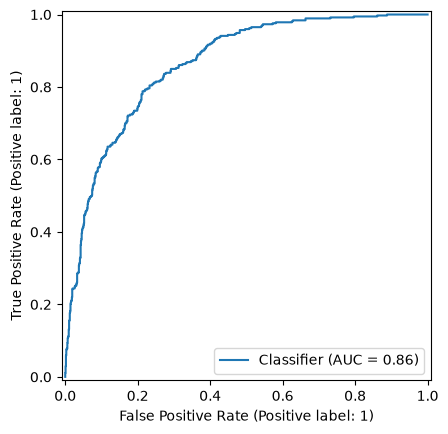

In [8]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

auc = roc_auc_score(y_test, probabilities[:, 1])
print("AUC-ROC:", auc)

RocCurveDisplay.from_predictions(y_test, probabilities[:, 1])
plt.show()

The ROC curve shows how the model balances true positives and false positives across different thresholds.  
The **AUC (Area Under the Curve)** summarizes this performance into a single score:  
- **0.5** → random guessing  
- **1.0** → perfect classifier  

In our churn model, the AUC is **0.86**, which indicates strong discriminative ability.  
This means the model correctly distinguishes churners from non‑churners about 86% of the time, even when accuracy is affected by class imbalance.  
A high AUC confirms that logistic regression is effective at ranking customers by churn risk, making it a reliable tool for retention strategies.


### Tools Used
Scikit-learn (LogisticRegression)  •  Pandas  •  Matplotlib  •  Jupyter Notebook